# Deconvolution of MNase-seq chromosome bins

March 29, 2024

Attempt to see if deconvolving the occupancy values for a chromosome can give a more clear replication timing profile.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [4]:
replicate = 2
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

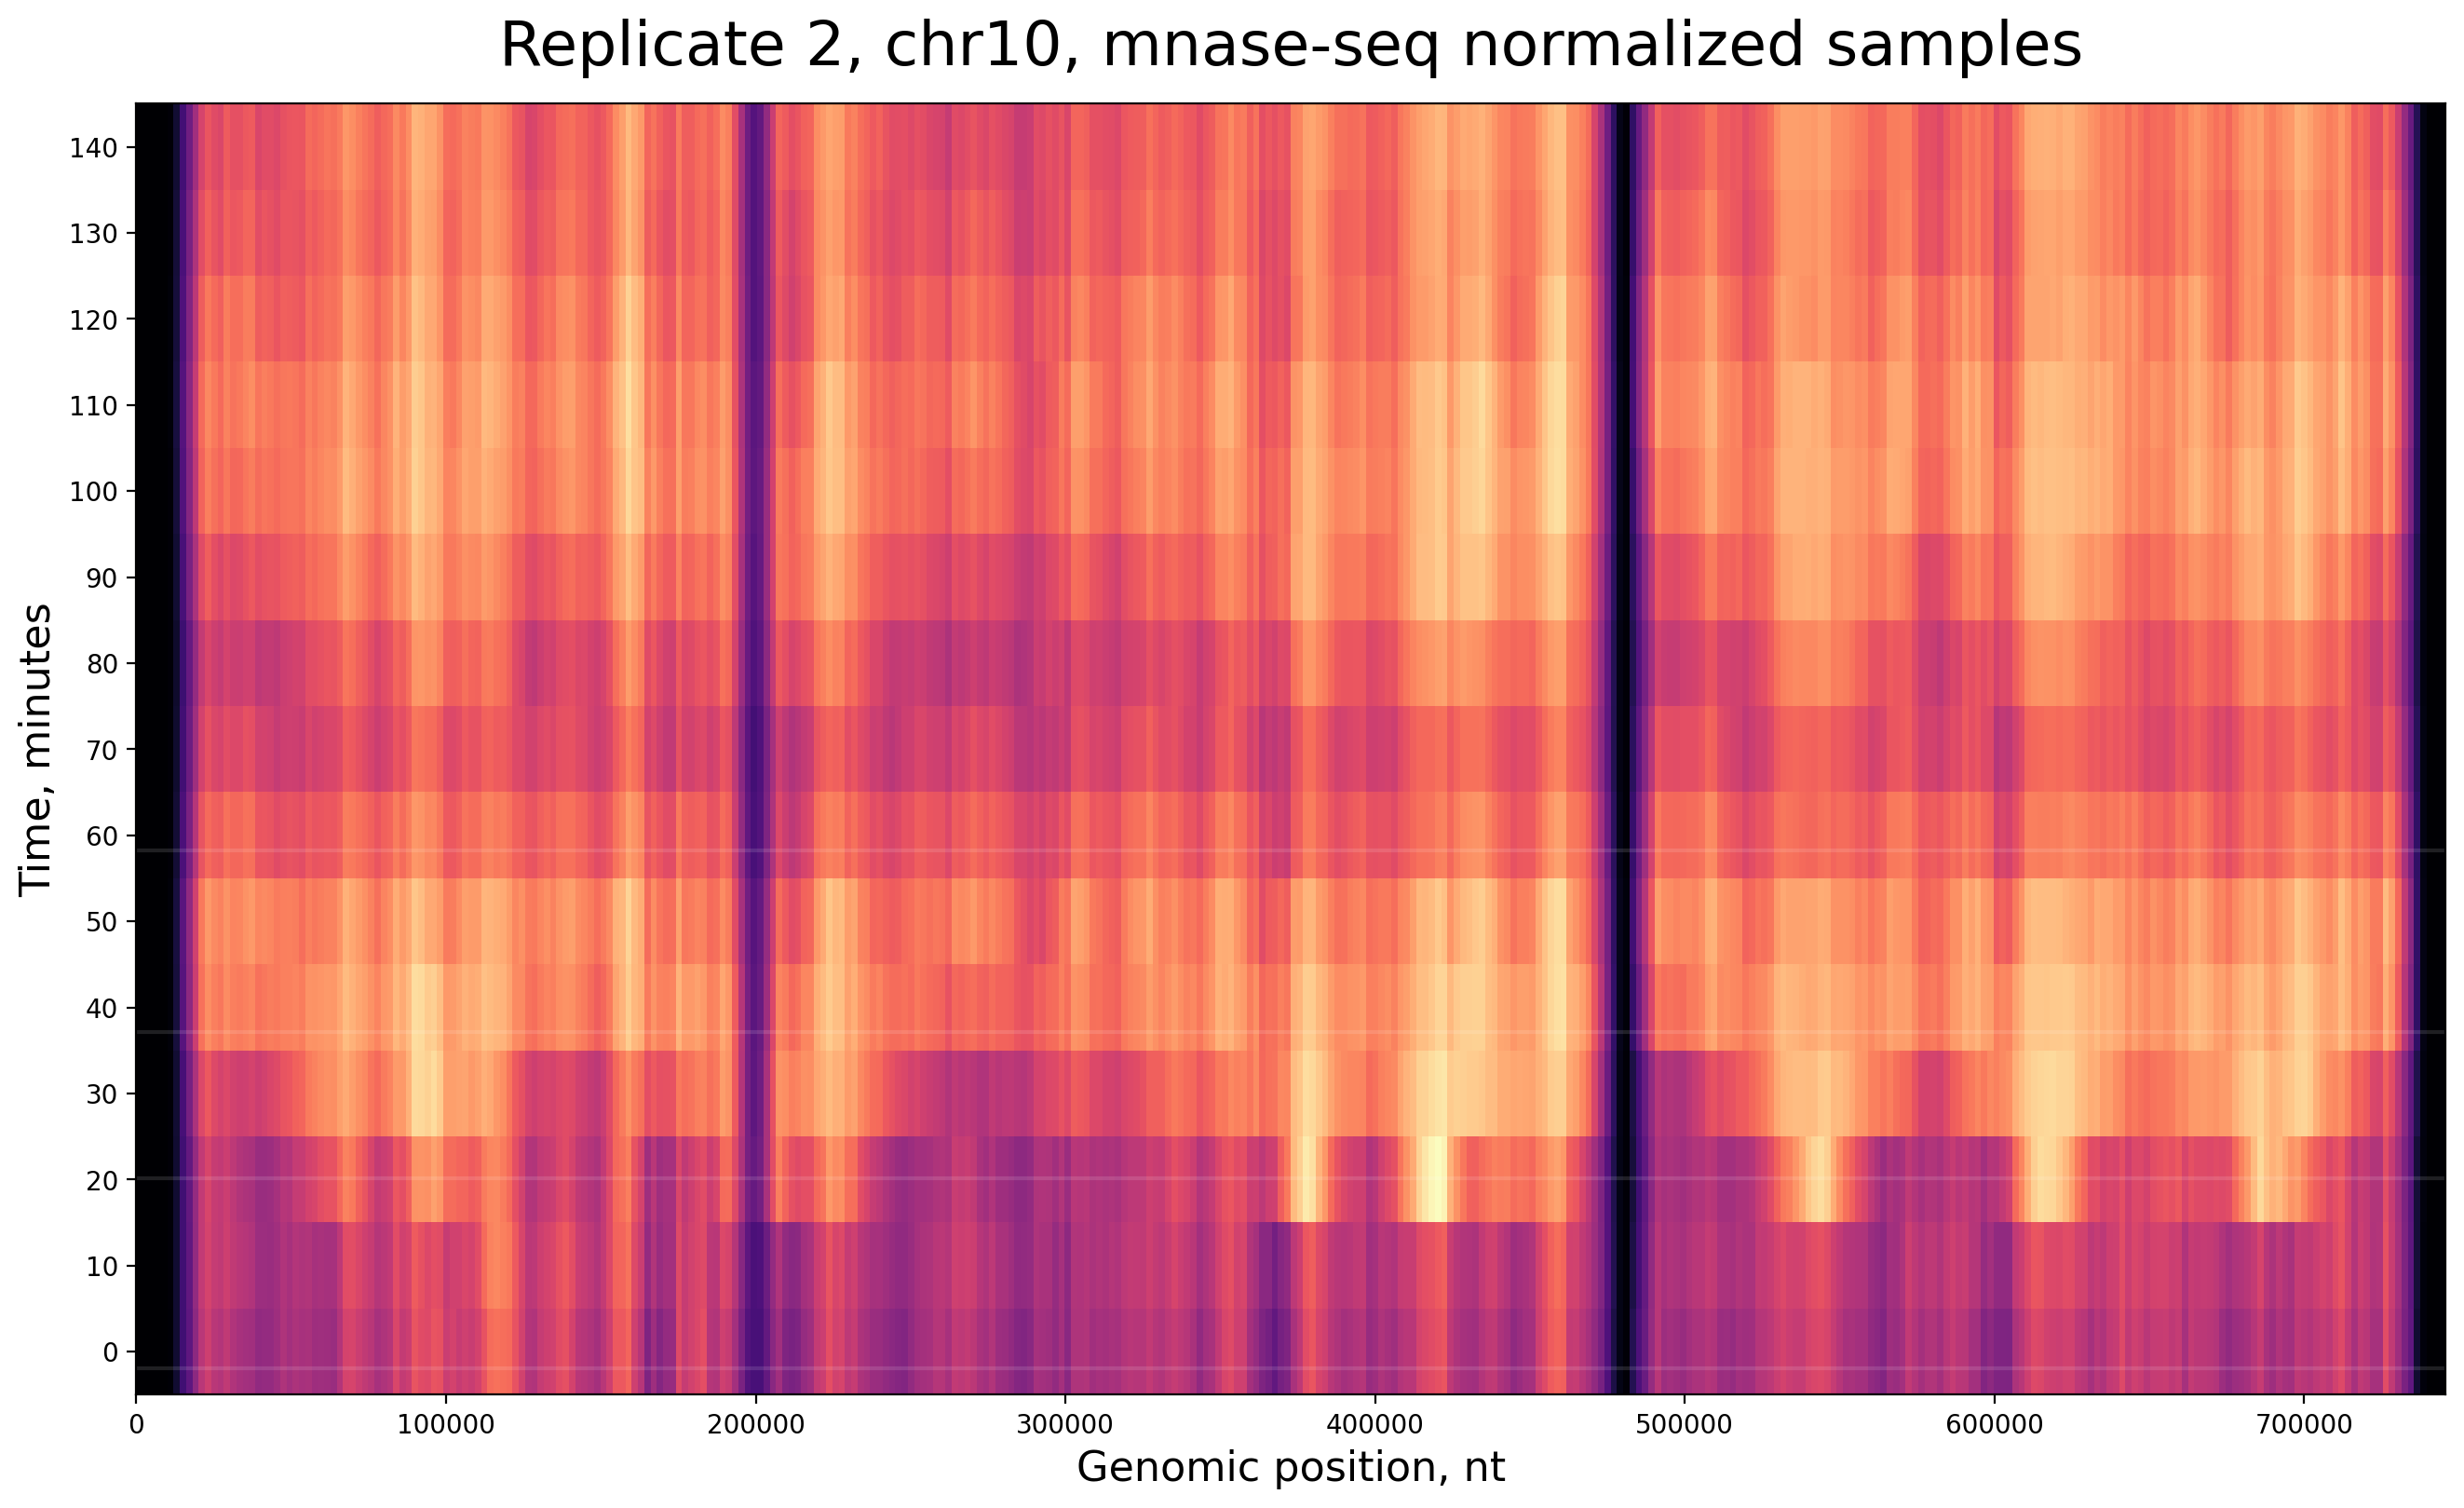

In [6]:
mnase_analysis.plot_heatmap()

In [7]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

config = load_yl_rg1_vst_config(replicate)
chromatin_model = ChromatinModel(config)

# Dummy gene
chromatin_model.load_mnase_gene('SEO1')

Loading MNase reads for YAL067C/SEO1...Loading chromosome reads: 1
Done.


In [8]:
chromatin_model.create_deconvolution_bins()
chromatin_model.setup_deconv_model()

In [9]:
chromatin_model.G = mnase_analysis.counts_normalized_by_copy

In [10]:
chromatin_model.G.shape

(15, 368)

In [11]:
chromatin_model.gamma = 0.0007
chromatin_model.setup_solver()
chromatin_model.deconvolve(verbose=True)

Deconvolving with gamma=0.0007, gamma_prime=0
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 29 04:03:14 PM: Your problem has 83536 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 29 04:03:14 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 29 04:03:14 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 29 04:03:14 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 29 04:03:14 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 29 04:03:14 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixS

(CVXPY) Mar 29 04:04:07 PM: Solver (including time spent in interface) took 2.912e+01 seconds
Deconvolved in : 00:00:53.542
The fitting norm is 0.08, the smoothing norm is: 18.53


In [12]:
deconvolved_counts = chromatin_model.get_deconv_results()[0].value

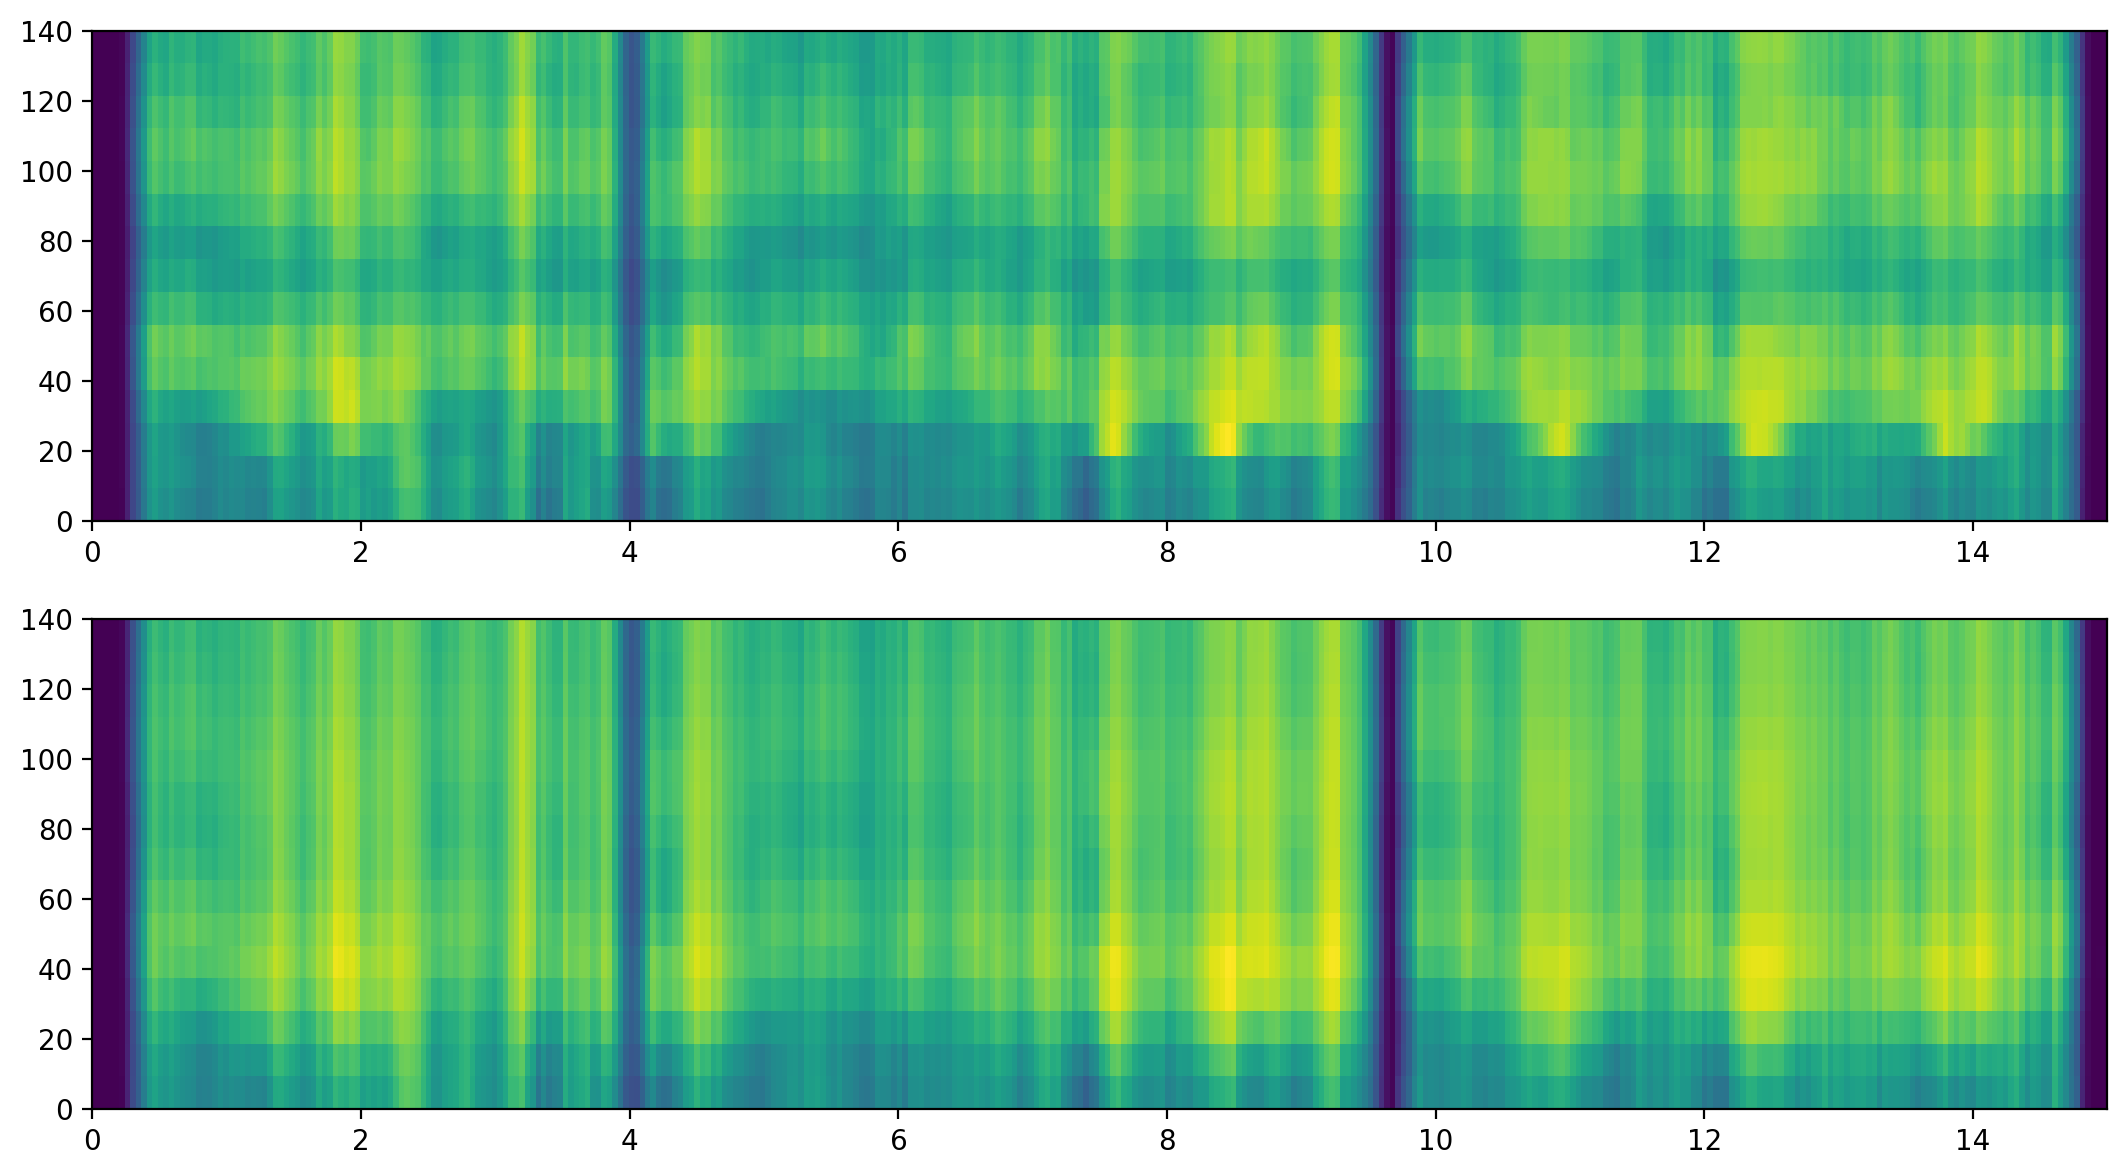

In [13]:
plt.figure(figsize=(13, 7))
plt.subplot(2, 1, 1)
plt.imshow(chromatin_model.G, origin='lower', cmap='viridis', aspect='auto',
          interpolation=None,
          extent=[0, chromatin_model.G.shape[0],
                 0, chromatin_model.timepoints[-1]])

pred_G = chromatin_model.deconv_model.H @ deconvolved_counts

plt.subplot(2, 1, 2)
plt.imshow(pred_G, origin='lower', cmap='viridis', aspect='auto',
          interpolation=None,
          extent=[0, chromatin_model.G.shape[0],
                 0, chromatin_model.timepoints[-1]])

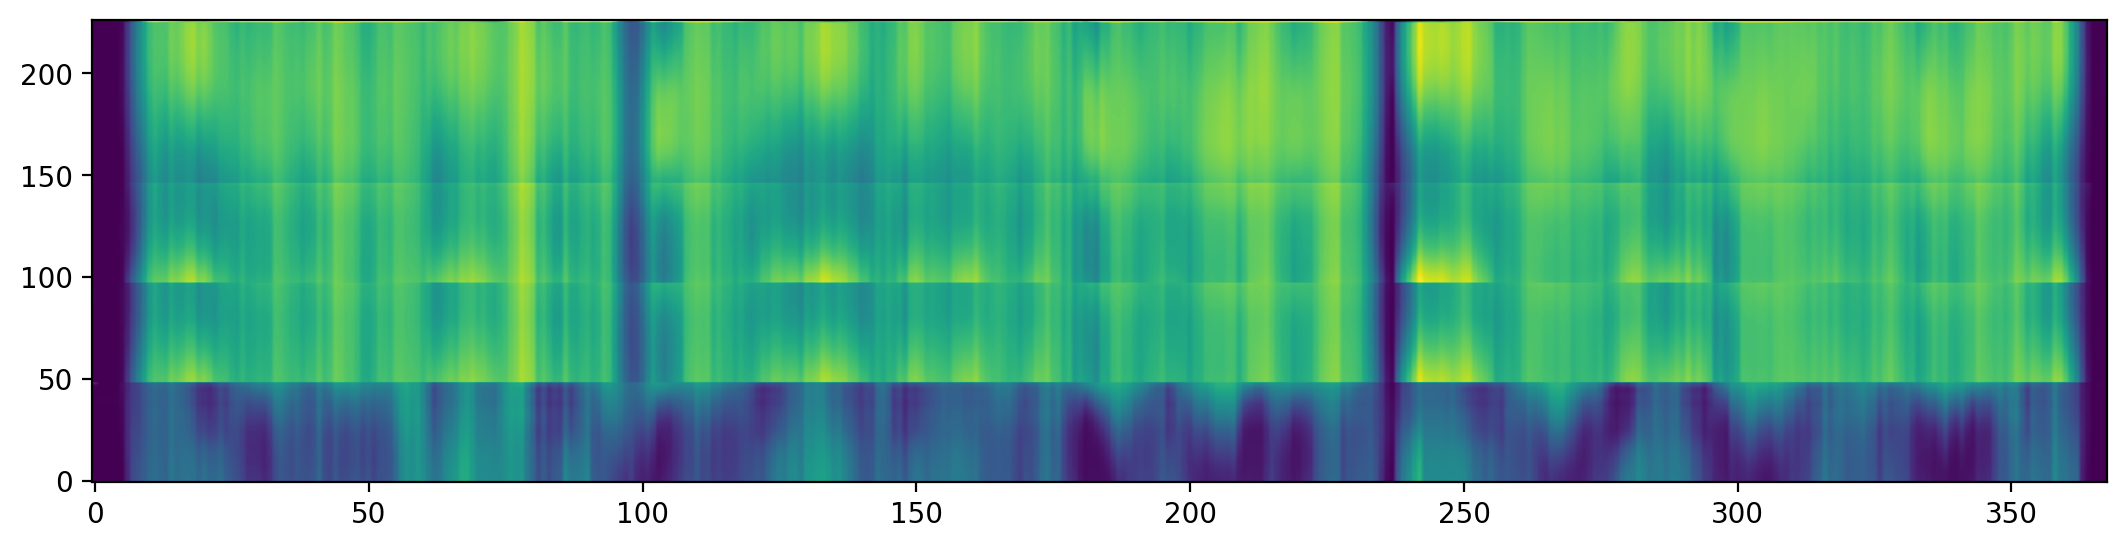

In [14]:
plt.figure(figsize=(13, 3))
plt.imshow(deconvolved_counts, origin='lower', cmap='viridis', aspect='auto',
          interpolation=None, vmax=2)

In [15]:
i_indices = chromatin_model.deconv_model.config.get_Hpositions_for_branch('i')
t_indices = chromatin_model.deconv_model.config.get_Hpositions_for_branch('t')
b_indices = chromatin_model.deconv_model.config.get_Hpositions_for_branch('b')

itb_indices = np.concatenate([i_indices, t_indices, b_indices])

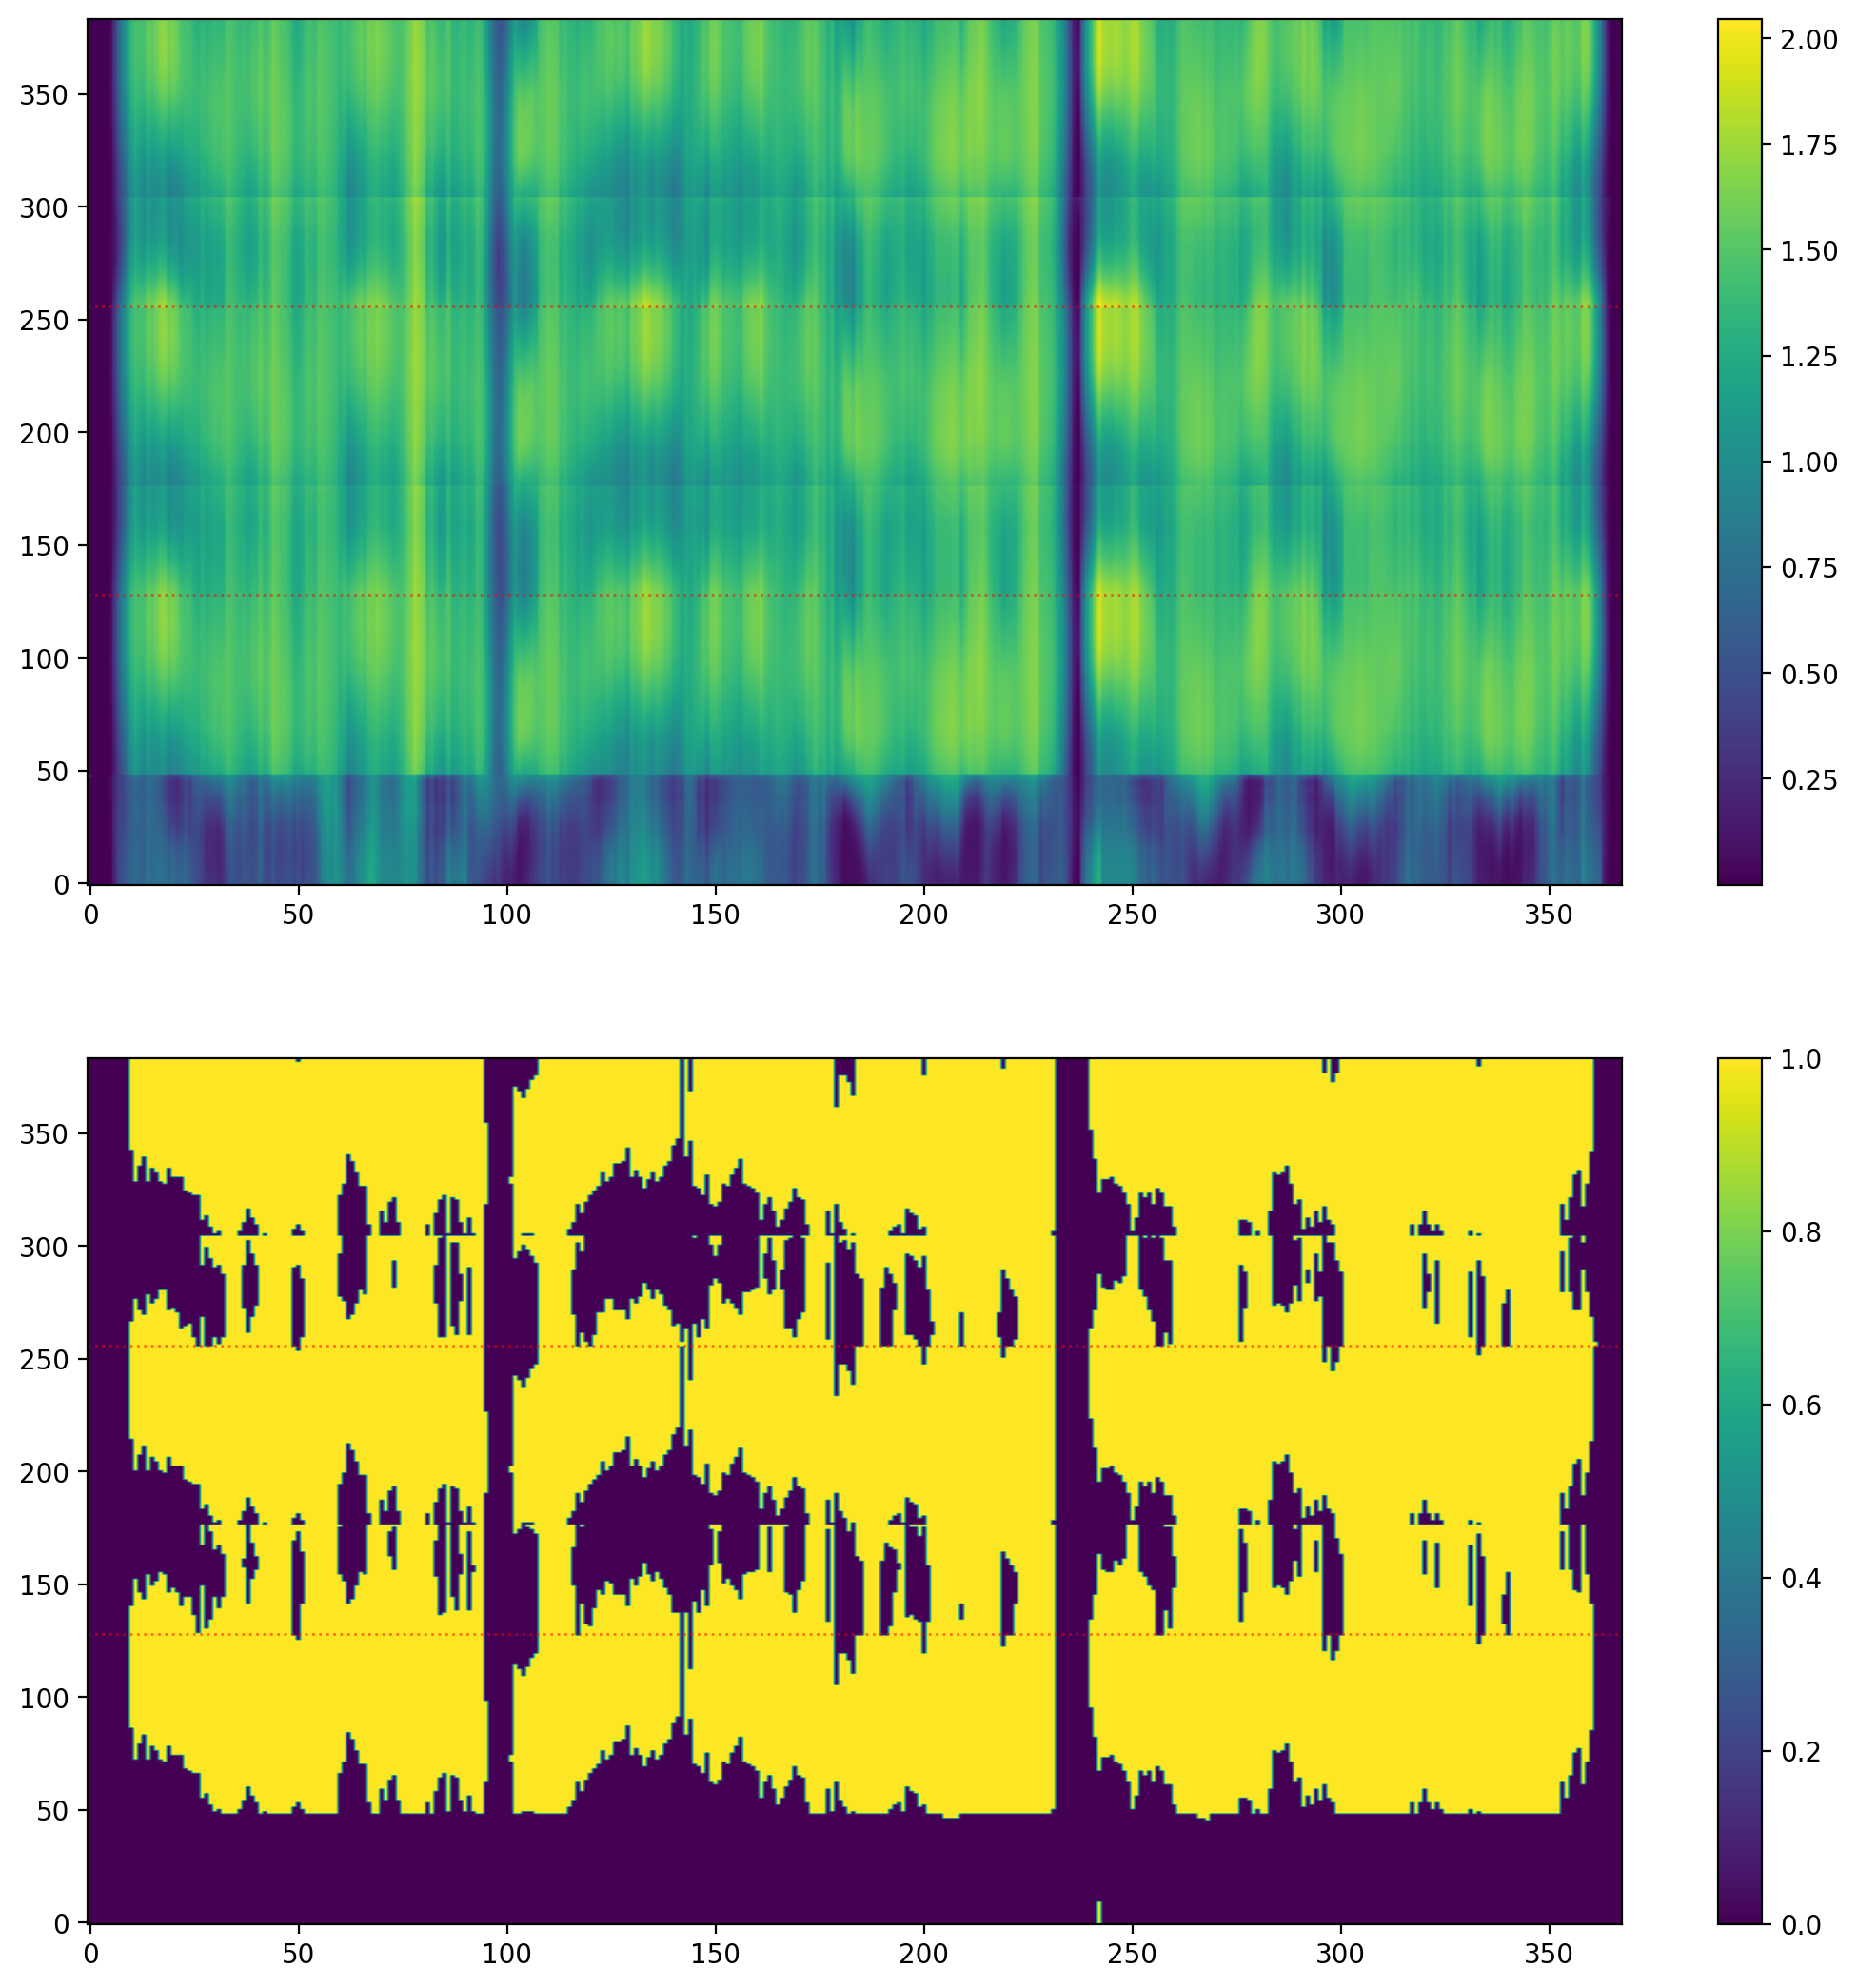

In [16]:
plt.figure(figsize=(13, 13))
plt.subplot(2, 1, 1)
plt.imshow(deconvolved_counts[itb_indices], origin='lower', cmap='viridis', aspect='auto',
          interpolation=None)
plt.colorbar()

plt.axhline(len(i_indices), c='red', alpha=0.5, lw=1, ls='dotted')
plt.axhline(len(i_indices) + len(t_indices), c='red', alpha=0.5, lw=1, ls='dotted')

plt.subplot(2, 1, 2)
plt.imshow(deconvolved_counts[itb_indices] > 1.25, origin='lower', 
    cmap='viridis', aspect='auto', interpolation=None)
plt.axhline(len(i_indices), c='red', alpha=0.5, lw=1, ls='dotted')
plt.axhline(len(i_indices) + len(t_indices), c='red', alpha=0.5, lw=1, ls='dotted')
plt.colorbar()


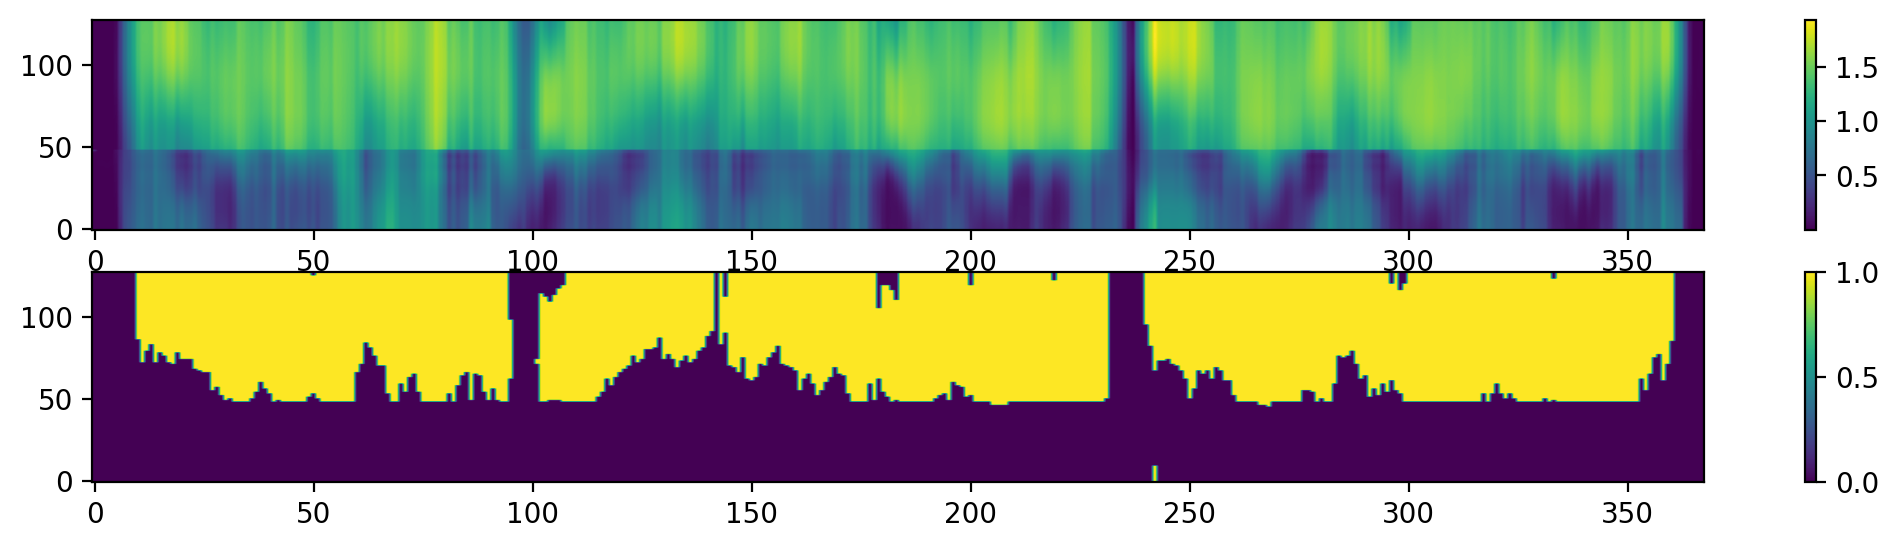

In [17]:
plt.figure(figsize=(13, 3))
plt.subplot(2, 1, 1)
plt.imshow(deconvolved_counts[i_indices], origin='lower', cmap='viridis', aspect='auto',
          interpolation=None)
plt.colorbar()

plt.subplot(2, 1, 2)
plt.imshow(deconvolved_counts[i_indices] > 1.25, origin='lower', 
    cmap='viridis', aspect='auto', interpolation=None)
plt.colorbar()
